# Load data from s3

In [72]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd

df = pd.read_csv('s3://ia340-2025-lab1/Electric_Vehicle_Population_Data.csv')
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB5K,Yakima,Yakima,WA,98901.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,15.0,347724772,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
1,1C4RJXU67R,Kitsap,Port Orchard,WA,98367.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,35.0,272165288,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
2,KNDCD3LD0N,Snohomish,Lynnwood,WA,98036.0,2022,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,0.0,32.0,203182584,POINT (-122.29245 47.82557),PUGET SOUND ENERGY INC,5.306105e+10
3,5UXKT0C37H,King,Auburn,WA,98001.0,2017,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,0.0,30.0,349010287,POINT (-122.23035 47.3074),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,1N4AZ0CP1D,Skagit,Mount Vernon,WA,98273.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,0.0,40.0,131684150,POINT (-122.33891 48.41644),PUGET SOUND ENERGY INC,5.305795e+10


# View the data

In [73]:
df.shape

(257635, 17)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257635 entries, 0 to 257634
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         257635 non-null  object 
 1   County                                             257627 non-null  object 
 2   City                                               257627 non-null  object 
 3   State                                              257635 non-null  object 
 4   Postal Code                                        257627 non-null  float64
 5   Model Year                                         257635 non-null  int64  
 6   Make                                               257635 non-null  object 
 7   Model                                              257635 non-null  object 
 8   Electric Vehicle Type                              257635 non-null  object

In [75]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,257627.000000,257635.000000,257632.000000,257632.000000,257038.000000,2.576350e+05,2.576270e+05
mean,98177.614217,2021.713164,43.127775,705.270541,28.897151,2.404009e+08,5.297530e+10
std,2535.922185,3.023857,81.632805,6997.364357,14.882168,6.602927e+07,1.597188e+09
min,1469.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.134322e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,0.000000,32.000000,2.586345e+08,5.303303e+10
75%,98380.000000,2024.000000,35.000000,0.000000,42.000000,2.738272e+08,5.305307e+10
max,99577.000000,2026.000000,337.000000,845000.000000,49.000000,4.792548e+08,6.601095e+10


# Markdown Explanation:
## According to the program, we have 257635 rows and 17 columns. Both numeric and text columns exist, but most columns are numeric (there appears to be 7 numeric, and 10 textual). My first impression is that the Electric Vehicle Type, model year, electric range, and model columns appear to be the most important.

# Clean the data

In [76]:
#rename column
df = df.rename(columns={'Postal Code': 'Zip Code'})
df.head()

,VIN (1-10),County,City,State,Zip Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB5K,Yakima,Yakima,WA,98901.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,15.0,347724772,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
1,1C4RJXU67R,Kitsap,Port Orchard,WA,98367.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,35.0,272165288,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
2,KNDCD3LD0N,Snohomish,Lynnwood,WA,98036.0,2022,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,0.0,32.0,203182584,POINT (-122.29245 47.82557),PUGET SOUND ENERGY INC,5.306105e+10
3,5UXKT0C37H,King,Auburn,WA,98001.0,2017,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,0.0,30.0,349010287,POINT (-122.23035 47.3074),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,1N4AZ0CP1D,Skagit,Mount Vernon,WA,98273.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,0.0,40.0,131684150,POINT (-122.33891 48.41644),PUGET SOUND ENERGY INC,5.305795e+10


In [77]:
df.isnull().sum() #show the number of rows containing null value

VIN (1-10)                                             0
County                                                 8
City                                                   8
State                                                  0
Zip Code                                               8
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         3
Base MSRP                                              3
Legislative District                                 597
DOL Vehicle ID                                         0
Vehicle Location                                      16
Electric Utility                                       8
2020 Census Tract                                      8
dtype: int64

In [78]:
df = df[df['Base MSRP']>0] # getting rid of 0 values
df = df[df['Electric Range']>0] # getting rid of 0 values
df = df.dropna() #drop null values
df.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Zip Code                                             0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

# Markdown Explanation:
## I renamed "Postal Code" to "Zip Code" and decided to drop all 659 na values.

# Manipulate the data

In [79]:
df['Electric Range'] #select a column 

77         17.0
86        208.0
125        93.0
167        93.0
308       208.0
          ...  
257239    208.0
257247    208.0
257288    208.0
257327     93.0
257632     15.0
Name: Electric Range, Length: 3167, dtype: float64

In [80]:
df.sort_values(by='Base MSRP') #sort data by a column

,VIN (1-10),County,City,State,Zip Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
137178,KNDJP3AE8G,King,Seattle,WA,98199.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,36.0,125566304,POINT (-122.40092 47.65908),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
151612,KNDJX3AE1G,Kitsap,Poulsbo,WA,98370.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,23.0,289165698,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
153285,KNDJX3AE3G,Clark,Vancouver,WA,98661.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,49.0,144894235,POINT (-122.62934 45.63201),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
138320,KNDJP3AEXG,Kitsap,Bremerton,WA,98311.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,23.0,244500119,POINT (-122.60915 47.62631),PUGET SOUND ENERGY INC,5.303509e+10
138496,KNDJX3AE2G,King,Seattle,WA,98115.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,46.0,134916519,POINT (-122.31676 47.68156),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95846,WP0AH2A7XJ,King,Kent,WA,98042.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,47.0,475425590,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
185874,WP0AH2A74J,Clark,Vancouver,WA,98662.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,17.0,145752232,POINT (-122.57722 45.64251),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
89107,WP0AH2A71J,Clark,Brush Prairie,WA,98606.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,18.0,107105750,POINT (-122.54578 45.73473),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
151787,WP0CA2A13F,King,Hunts Point,WA,98004.0,2015,PORSCHE,918,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,12.0,845000.0,48.0,100479039,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10


In [81]:
df[0:10] #slice

,VIN (1-10),County,City,State,Zip Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
77,JF2GTDNC6K,Yakima,Yakima,WA,98908.0,2019,SUBARU,CROSSTREK,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,17.0,34995.0,14.0,274959639,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10
86,5YJSA1H18E,Snohomish,Snohomish,WA,98290.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,39.0,186245370,POINT (-122.09305 47.91265),PUGET SOUND ENERGY INC,5.306105e+10
125,KNDJP3AE1G,Kitsap,Port Orchard,WA,98366.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,26.0,3481873,POINT (-122.63847 47.54103),PUGET SOUND ENERGY INC,5.303509e+10
167,KNDJX3AE5G,King,Bellevue,WA,98004.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,48.0,159884980,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
308,5YJSA1H15E,Skagit,Anacortes,WA,98221.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,40.0,137020670,POINT (-122.61214 48.51748),NO KNOWN ELECTRIC UTILITY SERVICE,5.305795e+10
423,5YJSA1CG1D,Snohomish,Gold Bar,WA,98251.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,39.0,136660828,POINT (-121.69743 47.85565),BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,5.306105e+10
476,5YJSA1H10E,Pierce,Anderson Island,WA,98303.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,28.0,132579814,POINT (-122.67876 47.17794),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
510,5YJSA1H14E,Snohomish,Snohomish,WA,98290.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,44.0,229698458,POINT (-122.09305 47.91265),PUGET SOUND ENERGY INC,5.306105e+10
559,5YJSA1DNXD,King,Auburn,WA,98001.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,30.0,205213333,POINT (-122.23035 47.3074),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
570,YV4BR0PL1J,King,North Bend,WA,98045.0,2018,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,64950.0,5.0,349204614,POINT (-121.7831 47.49348),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [82]:
df[df['Base MSRP']>150000] # select rows by values 

,VIN (1-10),County,City,State,Zip Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
29867,WP0CH2A78J,King,Seattle,WA,98126.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,34.0,281289088,POINT (-122.36893 47.54701),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
55943,WP0AH2A7XJ,Snohomish,Lake Stevens,WA,98258.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,44.0,144596238,POINT (-122.06402 48.01497),PUGET SOUND ENERGY INC,5.306105e+10
81654,WP0AH2A73J,Clark,Vancouver,WA,98662.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,17.0,183245247,POINT (-122.57722 45.64251),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
89107,WP0AH2A71J,Clark,Brush Prairie,WA,98606.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,18.0,107105750,POINT (-122.54578 45.73473),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
94863,WP0CH2A78J,King,Seattle,WA,98102.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,43.0,275425069,POINT (-122.32427 47.63433),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
95846,WP0AH2A7XJ,King,Kent,WA,98042.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,47.0,475425590,POINT (-122.09124 47.33778),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
104811,WP0AH2A70J,King,Bellevue,WA,98006.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,41.0,113244169,POINT (-122.12096 47.55584),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
146206,WP0CH2A75J,King,Sammamish,WA,98074.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,45.0,254562381,POINT (-122.02054 47.60326),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
151787,WP0CA2A13F,King,Hunts Point,WA,98004.0,2015,PORSCHE,918,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,12.0,845000.0,48.0,100479039,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
163684,WP0AH2A76J,King,Seatac,WA,98188.0,2018,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14.0,184400.0,33.0,277238377,POINT (-122.29179 47.43473),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


# Markdown Explanation:
## I selected the Electric Range column (which showed the ranges), sorted by Base MSRP (showed the cheapest cars first), and then sliced the first 10 rows. Finally, I filtered by the most expensive cars, all those greater than 150000

# Group & Visualize the data

Text(0.5, 0, 'County')

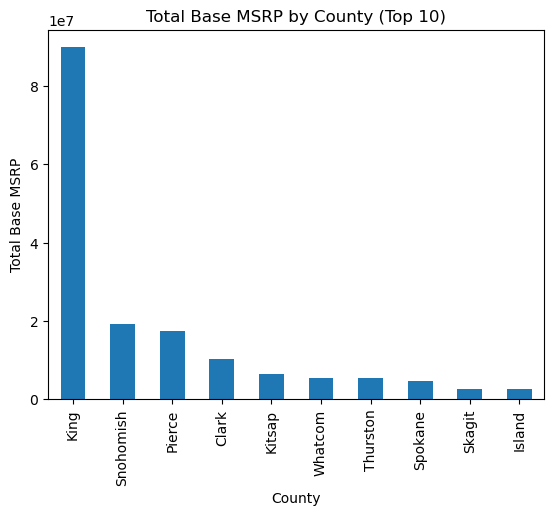

In [83]:
sum_cost_counties = df.groupby('County')['Base MSRP'].sum()
ax = sum_cost_counties.nlargest(10).plot.bar()

ax.set_title("Total Base MSRP by County (Top 10)")
ax.set_ylabel("Total Base MSRP")
ax.set_xlabel("County") 

## This bar chart displays the top 10 counties by total Base-MSRP of purchased vehicles. King County stands out, with a total MSRP much, much higher than any other county. Snohomish, Pierce, and Clark form a second tier with moderate totals, while the remaining counties show smaller totals. Overall, the chart shows a concentration of high valued vehicles in King County compared to other counties in the dataset.

Text(0, 0.5, 'Base MSRP ($)')

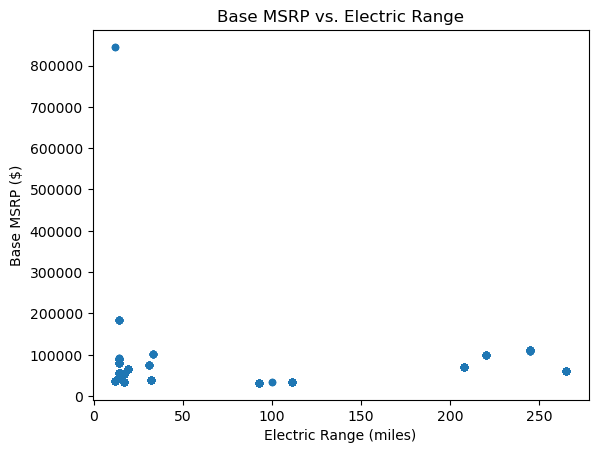

In [84]:
import matplotlib.pyplot as plt

ax = df.plot.scatter(
    x='Electric Range',
    y='Base MSRP'
)

ax.set_title("Base MSRP vs. Electric Range")
ax.set_xlabel("Electric Range (miles)")
ax.set_ylabel("Base MSRP ($)")

## The scatter plot shows Base MSRP on the y-axis and Electric Range on the x-axis for electric vehicles in Washington. Most cars cluster around low electric ranges (0–40 miles) with MSRPs between 30k and 120k USD. A few models with long ranges (around 200–260 miles) also fall in a similar MSRP band. One clear outlier appears at very low electric range and extremely high MSRP (around $850 USD). There is no strong linear relation observed.